=== DÉMONSTRATION DES CALCULS CHAMELEON ===

Cluster 1: [0, 1, 2]
Cluster 2: [3, 4, 5]

Relative Interconnectivity (RI): 0.0000
Relative Closeness (RC): 1.0000
Score de fusion (RI * RC^alpha): 0.0000

Matrice de similarité (extrait):
[[0.         0.5        0.5        0.        ]
 [0.5        0.         0.41421356 0.        ]
 [0.5        0.41421356 0.         0.        ]
 [0.         0.         0.         0.        ]]


=== TEST COMPLET DE CHAMELEON ===

Étape 1: Construction du graphe k-NN...
Étape 2: Partitionnement initial...
Nombre de clusters initiaux: 3
Étape 3: Fusion hiérarchique...
Critère d'arrêt atteint.

Nombre final de clusters: 3
Points non clusterisés: 0


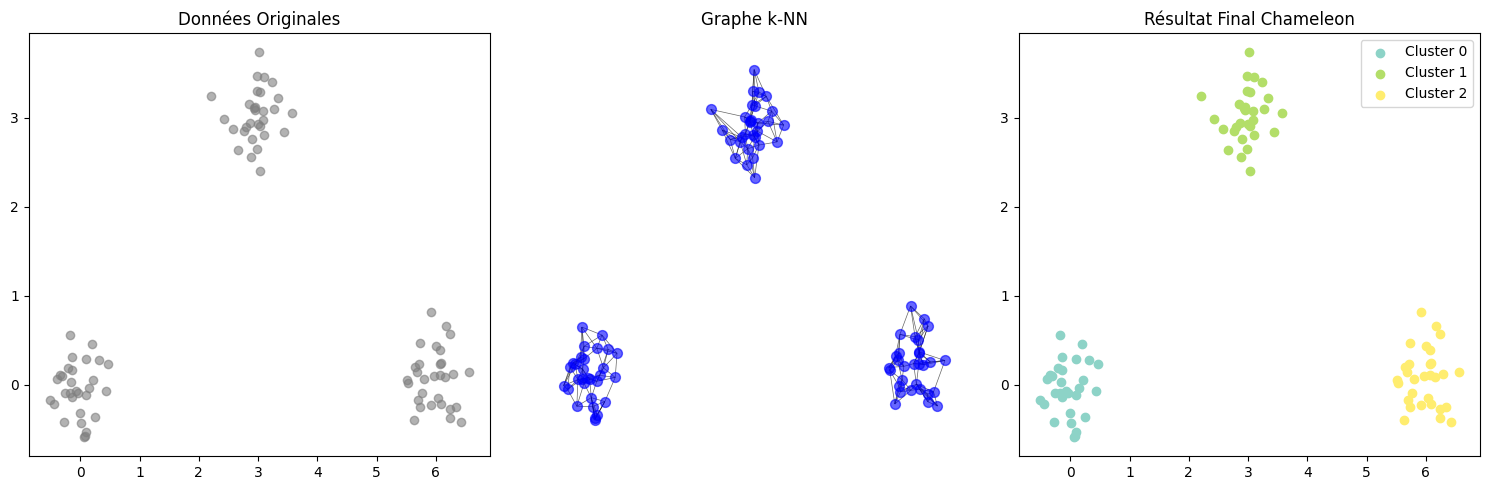

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import csr_matrix
import networkx as nx
from collections import defaultdict

class ChameleonClustering:
    def __init__(self, k=10, alpha=2.0, min_size=5):
        self.k = k  # nombre de voisins pour le graphe k-NN
        self.alpha = alpha  # paramètre pour le score de fusion
        self.min_size = min_size  # taille minimale des clusters initiaux
        
    def build_knn_graph(self, X):
        """Construit le graphe des k-plus proches voisins"""
        n_samples = X.shape[0]
        knn_graph = kneighbors_graph(X, self.k, mode='distance', include_self=False)
        
        # Convertir en matrice de similarité (inverse de la distance)
        similarity_matrix = knn_graph.copy()
        similarity_matrix.data = 1 / (1 + similarity_matrix.data)  # Éviter division par zéro
        
        return similarity_matrix
    
    def initial_partitioning(self, graph):
        """Partitionnement initial simple basé sur les composantes connexes"""
        G = nx.from_scipy_sparse_array(graph)
        components = list(nx.connected_components(G))
        
        # Filtrer les petites composantes
        initial_clusters = [list(comp) for comp in components if len(comp) >= self.min_size]
        
        return initial_clusters
    
    def compute_EC(self, cluster_i, cluster_j, graph):
        """Calcule EC(Ci, Cj) - somme des arêtes entre les clusters"""
        total_weight = 0
        for node_i in cluster_i:
            for node_j in cluster_j:
                if graph[node_i, node_j] > 0:
                    total_weight += graph[node_i, node_j]
        return total_weight
    
    def compute_internal_EC(self, cluster, graph):
        """Calcule EC(C) - coupe minimale pour diviser le cluster"""
        if len(cluster) <= 1:
            return 0
            
        # Méthode simplifiée : somme des poids des arêtes les plus faibles
        subgraph = graph[np.ix_(cluster, cluster)]
        if subgraph.nnz == 0:
            return 0
            
        # Calculer la coupe minimale approximative
        weights = []
        for node in cluster:
            node_weights = []
            for neighbor in cluster:
                if neighbor != node and graph[node, neighbor] > 0:
                    node_weights.append(graph[node, neighbor])
            if node_weights:
                weights.append(min(node_weights))
        
        return min(weights) if weights else 0
    
    def compute_RI(self, cluster_i, cluster_j, graph):
        """Calcule la Relative Interconnectivity"""
        EC_ij = self.compute_EC(cluster_i, cluster_j, graph)
        EC_i = self.compute_internal_EC(cluster_i, graph)
        EC_j = self.compute_internal_EC(cluster_j, graph)
        
        if EC_i + EC_j == 0:
            return 0
            
        RI = EC_ij / (0.5 * (EC_i + EC_j))
        return RI
    
    def compute_average_similarity(self, cluster, graph):
        """Calcule S̄EC(C) - similarité moyenne dans le cluster"""
        if len(cluster) <= 1:
            return 0
            
        total_similarity = 0
        count = 0
        
        for i, node_i in enumerate(cluster):
            for j, node_j in enumerate(cluster):
                if i < j and graph[node_i, node_j] > 0:
                    total_similarity += graph[node_i, node_j]
                    count += 1
        
        return total_similarity / count if count > 0 else 0
    
    def compute_RC(self, cluster_i, cluster_j, graph):
        """Calcule la Relative Closeness"""
        S_EC_ij = self.compute_average_similarity(list(cluster_i) + list(cluster_j), graph)
        S_EC_i = self.compute_average_similarity(cluster_i, graph)
        S_EC_j = self.compute_average_similarity(cluster_j, graph)
        
        m_i = len(cluster_i)
        m_j = len(cluster_j)
        
        denominator = (m_i / (m_i + m_j)) * S_EC_i + (m_j / (m_i + m_j)) * S_EC_j
        
        if denominator == 0:
            return 0
            
        RC = S_EC_ij / denominator
        return RC
    
    def compute_merge_score(self, cluster_i, cluster_j, graph):
        """Calcule le score de fusion RI * RC^alpha"""
        RI = self.compute_RI(cluster_i, cluster_j, graph)
        RC = self.compute_RC(cluster_i, cluster_j, graph)
        
        return RI * (RC ** self.alpha)
    
    def fit(self, X):
        """Applique l'algorithme Chameleon"""
        self.X = X
        n_samples = X.shape[0]
        
        print("Étape 1: Construction du graphe k-NN...")
        self.graph = self.build_knn_graph(X)
        
        print("Étape 2: Partitionnement initial...")
        self.clusters = self.initial_partitioning(self.graph)
        print(f"Nombre de clusters initiaux: {len(self.clusters)}")
        
        print("Étape 3: Fusion hiérarchique...")
        iteration = 0
        while True:
            iteration += 1
            best_score = -1
            best_pair = None
            
            # Trouver la meilleure paire à fusionner
            for i in range(len(self.clusters)):
                for j in range(i + 1, len(self.clusters)):
                    score = self.compute_merge_score(self.clusters[i], self.clusters[j], self.graph)
                    if score > best_score:
                        best_score = score
                        best_pair = (i, j)
            
            # Critère d'arrêt
            if best_score <= 0 or len(self.clusters) <= 1:
                print("Critère d'arrêt atteint.")
                break
                
            # Fusionner les clusters
            i, j = best_pair
            new_cluster = self.clusters[i] + self.clusters[j]
            
            # Mettre à jour la liste des clusters
            if i > j:
                self.clusters.pop(i)
                self.clusters.pop(j)
            else:
                self.clusters.pop(j)
                self.clusters.pop(i)
                
            self.clusters.append(new_cluster)
            
            print(f"Itération {iteration}: Fusionné clusters {i} et {j}, score={best_score:.4f}")
            print(f"Clusters restants: {len(self.clusters)}")
            
            if iteration >= 20:  # Limite de sécurité
                print("Limite d'itérations atteinte.")
                break
        
        # Assigner les labels finaux
        self.labels_ = np.full(n_samples, -1)
        for cluster_id, cluster in enumerate(self.clusters):
            for point_idx in cluster:
                self.labels_[point_idx] = cluster_id
                
        return self

# Fonction pour visualiser les résultats
def visualize_chameleon(X, labels, title="Clustering Chameleon"):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.6)
    plt.title("Données Originales")
    
    plt.subplot(1, 3, 2)
    # Visualiser le graphe k-NN
    chameleon = ChameleonClustering(k=5)
    graph = chameleon.build_knn_graph(X)
    G = nx.from_scipy_sparse_array(graph)
    
    pos = {i: X[i] for i in range(len(X))}
    nx.draw(G, pos, node_size=50, node_color='blue', alpha=0.6, width=0.5)
    plt.title("Graphe k-NN")
    
    plt.subplot(1, 3, 3)
    unique_labels = np.unique(labels)
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))
    
    for label, color in zip(unique_labels, colors):
        if label == -1:
            continue
        mask = labels == label
        plt.scatter(X[mask, 0], X[mask, 1], c=[color], label=f'Cluster {label}')
    
    plt.title(title)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Exemple d'utilisation avec démonstration des calculs
def demonstrate_calculations():
    """Démontre les calculs de RI et RC avec un exemple simple"""
    print("=== DÉMONSTRATION DES CALCULS CHAMELEON ===\n")
    
    # Créer un exemple simple avec 6 points
    X_small = np.array([
        [1, 1], [1, 2], [2, 1],  # Cluster 1
        [5, 5], [5, 6], [6, 5]   # Cluster 2
    ])
    
    chameleon = ChameleonClustering(k=2)
    graph = chameleon.build_knn_graph(X_small)
    
    # Définir manuellement deux clusters
    cluster1 = [0, 1, 2]  # Points 0,1,2
    cluster2 = [3, 4, 5]  # Points 3,4,5
    
    print("Cluster 1:", cluster1)
    print("Cluster 2:", cluster2)
    print()
    
    # Calculer RI
    RI = chameleon.compute_RI(cluster1, cluster2, graph)
    print(f"Relative Interconnectivity (RI): {RI:.4f}")
    
    # Calculer RC
    RC = chameleon.compute_RC(cluster1, cluster2, graph)
    print(f"Relative Closeness (RC): {RC:.4f}")
    
    # Calculer le score de fusion
    score = chameleon.compute_merge_score(cluster1, cluster2, graph)
    print(f"Score de fusion (RI * RC^alpha): {score:.4f}")
    print()
    
    # Afficher les similarités dans le graphe
    print("Matrice de similarité (extrait):")
    dense_graph = graph.toarray()
    print(dense_graph[:4, :4])  # Afficher les 4 premières lignes/colonnes

# Test avec des données synthétiques
def test_chameleon():
    """Test complet de l'algorithme Chameleon"""
    print("=== TEST COMPLET DE CHAMELEON ===\n")
    
    # Générer des données de test
    np.random.seed(42)
    
    # Cluster 1
    cluster1 = np.random.normal([0, 0], 0.3, (30, 2))
    # Cluster 2
    cluster2 = np.random.normal([3, 3], 0.3, (30, 2))
    # Cluster 3
    cluster3 = np.random.normal([6, 0], 0.3, (30, 2))
    
    X = np.vstack([cluster1, cluster2, cluster3])
    
    # Appliquer Chameleon
    chameleon = ChameleonClustering(k=5, alpha=2.0, min_size=3)
    chameleon.fit(X)
    
    # Afficher les résultats
    print(f"\nNombre final de clusters: {len(np.unique(chameleon.labels_))}")
    print(f"Points non clusterisés: {np.sum(chameleon.labels_ == -1)}")
    
    # Visualiser
    visualize_chameleon(X, chameleon.labels_, "Résultat Final Chameleon")
    
    return chameleon

if __name__ == "__main__":
    # Démontrer les calculs
    demonstrate_calculations()
    
    print("\n" + "="*50 + "\n")
    
    # Lancer le test complet
    chameleon = test_chameleon()